# 05 - Defending against Adversarial Examples

We saw how to attack models, but we also need to take into account defending against them.
In particular, we will learn here how to create a simplified version of **adversarial training**.

As seen in class, this technique is defined as:
$$
\min_{\boldsymbol{\theta}} \sum_{(\boldsymbol{x},y) \in D} \max_{\boldsymbol{\delta}} L(\boldsymbol{x}+\boldsymbol{\delta}, y;\boldsymbol{\theta})
$$

which accounts for computing the best parameters $\boldsymbol{\theta}$ that minimizes the error in the presence of worst-case adversarial noise $\boldsymbol{\delta}$.

This is nice in theory, but implementing this is hard and resource demanding.

In [1]:
try:
    import secmlt
except ImportError:
    print("Installing the dependancies")
    %pip install git+https://github.com/pralab/secml-torch


In [2]:
import torch
import numpy as np
import random

seed = 999
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

from secmlt.models.pytorch.base_pytorch_nn import BasePytorchClassifier
from secmlt.models.pytorch.base_pytorch_trainer import BasePyTorchTrainer
from secmlt.metrics.classification import Accuracy
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
import torch


def plot_decision_regions(model, X, y, title="Decision Regions"):
    """
    Plot decision regions for a PyTorch model.
    
    Args:
        model: PyTorch model (must be in eval mode)
        X: Input features as tensor
        y: Labels as tensor
        title: Plot title
    """
    # Convert tensors to numpy for plotting
    X_np = X.detach().numpy()
    y_np = y.detach().numpy()
    
    # Create a mesh grid
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                        np.linspace(y_min, y_max, 200))
    
    # Get predictions for each point in the mesh
    X_mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        model.eval()
        Z = model(X_mesh)
        Z = torch.argmax(Z, dim=1)
    Z = Z.numpy().reshape(xx.shape)
    
    # Plot decision regions
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    
    # Plot data points
    scatter = plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, 
                         cmap='viridis')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.show()


centers = [(0, 1), (0, 0), (1, 1)]
cluster_std = 0.25
X_train, y_train = make_blobs(n_samples=500, 
                  centers=centers,
                  n_features=2,
                  cluster_std=cluster_std,
                  random_state=seed)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test, y_test = make_blobs(n_samples=100, 
                  centers=centers,
                  n_features=2,
                  cluster_std=cluster_std,
                  random_state=seed)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)


tr_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)
ts_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=5, shuffle=False)

class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = torch.nn.Linear(2, 32)  
        self.fc2 = torch.nn.Linear(32, 16)
        self.fc3 = torch.nn.Linear(16, 3)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

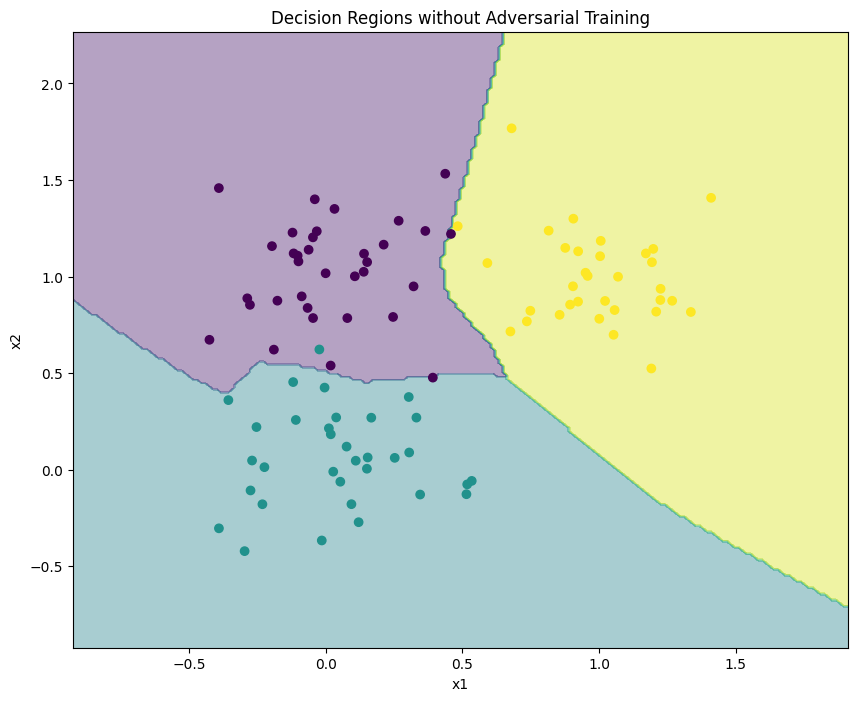

In [3]:
epochs = 1000
lr = 1e-3

net2 = Net()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net2.parameters(), lr=lr)

trainer = BasePyTorchTrainer(optimizer=optimizer, loss=criterion, epochs=epochs)
secmlt_model = BasePytorchClassifier(net2, trainer=trainer)
secmlt_model.train(tr_dataloader)

plot_decision_regions(secmlt_model.model, X_test, y_test, title="Decision Regions without Adversarial Training")

Given this network, we need to tweak the training loop that we saw at the beginning of the course.
Since we have a deep neural network, we **can not** compute adversarial training in closed form.

Hence, the only way is *approximating* the technique by iteratively create adversarial examples while optimizing.
This can be done in multiple ways:

* at each iteration, we create adversarial examples and include them in training (very time consuming)
* train the model for some epochs, compute adversarial attacks, include them in the training, repeat
* fine-tune the trained model with one attack with larger epsilon (less granular, but fast)

Here we are going to use a very easy approach, through Fast Gradient Sign Method (FGSM), which is a single-step attack with a large L-infinity norm.

#### My Notes
se riduco il numero di epoch, in generale la boundary cambia notevolmente. Solo per darvi un’altra intuizione sui problemi nella sicurezza del machine learning.
Guardate qui, la boundary è cambiata tantissimo, ok? Vedete che qui non c’è più la curva.
Quindi, a volte, la sicurezza di un modello dipende moltissimo anche da come è stato addestrato.



1. Primo loss.backward(): serve solo per ottenere il gradiente rispetto all’input
   
Scopo:

- Calcolare il gradiente della loss rispetto all’immagine.
- Questo gradiente serve solo per costruire l’esempio avversario inputs_adv.

1. Secondo loss.backward(): serve per addestrare il modello 
   
Scopo:

- Calcolare i gradienti dei pesi della rete rispetto alla loss sugli esempi avversari.
- L’ottimizzatore usa questi gradienti per aggiornare i parametri del modello.

In [4]:
model= Net()

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.CrossEntropyLoss()

epsilon = 0.3

for epoch in range(epochs):
    running_loss = 0.0
    for inputs, labels in tr_dataloader:
        # Compute adversarial samples with 1-iteration attack
        model.eval()
        x = inputs.clone().detach().requires_grad_(True)
        outputs = model(x)
        loss = criterion(outputs, labels) # calculate the loss on the actual labels.
        loss.backward()
        # Now, in gradient, I have the vector pointing towards the maximum increase in loss. 
        # So, if I do something like + gradient, I am looking for the point of maximum error in the function.
        gradient = x.grad.data
        inputs_adv = x.data + epsilon * torch.sign(gradient)

        # Compute loss and backpropagate as usual
        model.train()
        optimizer.zero_grad()
        outputs = model(inputs_adv)
        loss = criterion(outputs, labels)
        loss.backward()                 
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(tr_dataloader.dataset)
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

at_model = BasePytorchClassifier(model)

Epoch 100, Loss: 0.6547
Epoch 200, Loss: 0.6502
Epoch 300, Loss: 0.6425
Epoch 400, Loss: 0.6336
Epoch 500, Loss: 0.6302
Epoch 600, Loss: 0.6117
Epoch 700, Loss: 0.5802
Epoch 800, Loss: 0.5500
Epoch 900, Loss: 0.5083
Epoch 1000, Loss: 0.4988


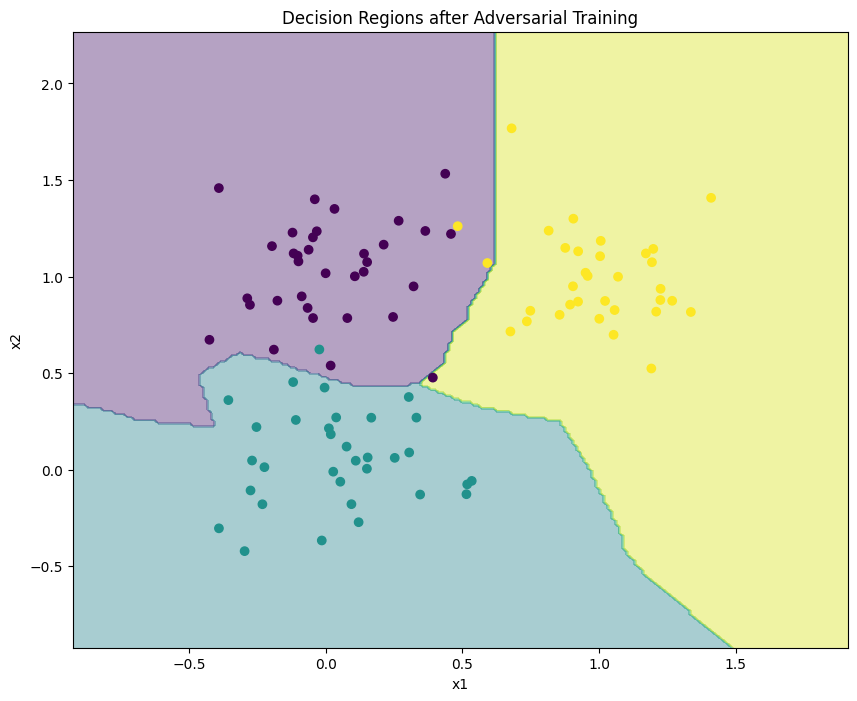

In [5]:
plot_decision_regions(model, X_test, y_test, title="Decision Regions after Adversarial Training")

# Exercise 1
* Perform a security evaluation of both model under the same attack condition (for simplicity, use a PGD attack with varying epsilon)
* Plot the security evaluation curves in the same plot, and try to understand what the comparison is telling regarding the robustness of these models.

In [6]:
from secmlt.adv.evasion.pgd import PGD
from secmlt.adv.backends import Backends
from secmlt.adv.evasion.perturbation_models import LpPerturbationModels

def security_evaluation_pgd_linf(model, testloader, epsilons, iterations=100, stepsize=0.01):
    sec_eval_data = []
    for e in epsilons:
        attack = PGD(
            perturbation_model=LpPerturbationModels.LINF,
            num_steps=iterations,
            step_size=stepsize,
            y_target=None,
            epsilon=e,
            lb=-2,ub=2,
            backend = Backends.NATIVE)
        adv_dataloader = attack(model, testloader)
        robust_accuracy = Accuracy()(model, adv_dataloader)
        sec_eval_data.append(robust_accuracy)
    return sec_eval_data

In [7]:
epsilons = torch.linspace(0, 1.5, steps=10)
iterations = 500
security_eval_no_at = security_evaluation_pgd_linf(secmlt_model, ts_dataloader, epsilons=epsilons,iterations=iterations, stepsize=0.1)
security_eval_at = security_evaluation_pgd_linf(at_model, ts_dataloader, epsilons=epsilons,iterations=iterations, stepsize=0.1)

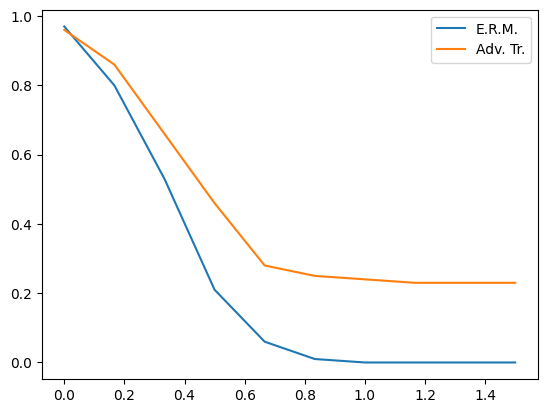

In [8]:
import matplotlib.pyplot as plt

plt.plot(epsilons.numpy(), security_eval_no_at, label='E.R.M.')
plt.plot(epsilons.numpy(), security_eval_at, label='Adv. Tr.')
plt.legend()
plt.show()

Lcurva blu (ERM) è più alta a epsilon = 0

Il modello ERM ha:

- alta accuratezza standard (non ha vincoli)
- boundary più “fina e precisa”, molto vicina ai campioni

L’adversarial training invece:

- deforma la decision boundary,
- la rende più “arretrata” rispetto ai campioni,
- rende la funzione più liscia e conservativa.

Questo rende più difficile classificare perfettamente i dati:
→ una leggera perdita di accuratezza standard.

Man mano che ε cresce:

- l’attacco PGD diventa più forte,
- le immagini vengono modificate molto,
- e il modello normale (blu) collassa molto presto.

Quindi

- la curva blu scende rapidamente fino quasi allo zero.
- la curva arancione rimane più alta a parità di epsilon.

Questo significa:
→ il modello con adversarial training è più difficile da attaccare.



- L’adversarial training allarga le regioni sicure attorno ai dati.
- Ogni campione viene considerato come una palla L∞ di raggio ε.
- La decision boundary viene “spinta fuori” per includere tutta la palla.
- Appiattisce la funzione e agisce come una forte regularizzazione.

# Exercise 2

* Try to change the attack used in adversarial training, for instance using PGD or by increasing the epsilon. What happens if epsilon is too large?
* What happens if the model does not have too many parameters? Can you successfully train it with adversarial training?
* What happens if I perform an L1 attack against a model that has been trained with L∞ perturbations?

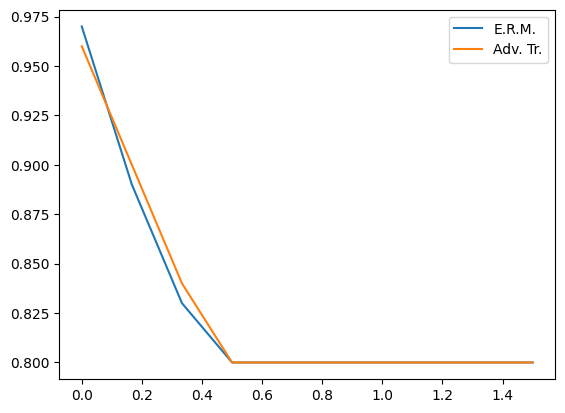

In [11]:

def security_evaluation_pgd_l1(model, testloader, epsilons, iterations=100, stepsize=0.01):
    sec_eval_data = []
    for e in epsilons:
        attack = PGD(
            perturbation_model=LpPerturbationModels.L1,
            num_steps=iterations,
            step_size=stepsize,
            y_target=None,
            epsilon=e,
            lb=-2,ub=2,
            backend = Backends.NATIVE)
        adv_dataloader = attack(model, testloader)
        robust_accuracy = Accuracy()(model, adv_dataloader)
        sec_eval_data.append(robust_accuracy)
    return sec_eval_data

epsilons = torch.linspace(0, 1.5, steps=10)
iterations = 500
security_eval_no_at = security_evaluation_pgd_l1(secmlt_model, ts_dataloader, epsilons=epsilons,iterations=iterations, stepsize=0.1)
security_eval_at = security_evaluation_pgd_l1(at_model, ts_dataloader, epsilons=epsilons,iterations=iterations, stepsize=0.1)

# Plot comparison
plt.plot(epsilons.numpy(), security_eval_no_at, label='E.R.M.')
plt.plot(epsilons.numpy(), security_eval_at, label='Adv. Tr.')
plt.legend()
plt.show()

Quando si esegue un attacco L1 contro un modello addestrato con perturbazioni L∞, è probabile che si osservi una robustezza ridotta rispetto all'attacco con L∞. Ecco perché:

- L∞ (addestramento avversario): crea perturbazioni in cui ogni caratteristica cambia al massimo di ε. Il modello impara a essere robusto nei confronti di piccole variazioni uniformi su tutte le dimensioni.

- L1 (attacco): crea perturbazioni sparse in cui la somma totale delle variazioni assolute è limitata, ma le singole caratteristiche possono cambiare in modo significativo.


il modello non è stato addestrato per difendersi dalle perturbazioni L1, quindi potrebbe essere vulnerabile a questa diversa geometria di attacco.

